### ResNet整体架构
- ResNet提供了ResNet-18，ResNet-34，ResNet-50，ResNet-101，ResNet-152等不同的版本。后边的数字代表不同的网络层数。
#### ResNet-18架构图
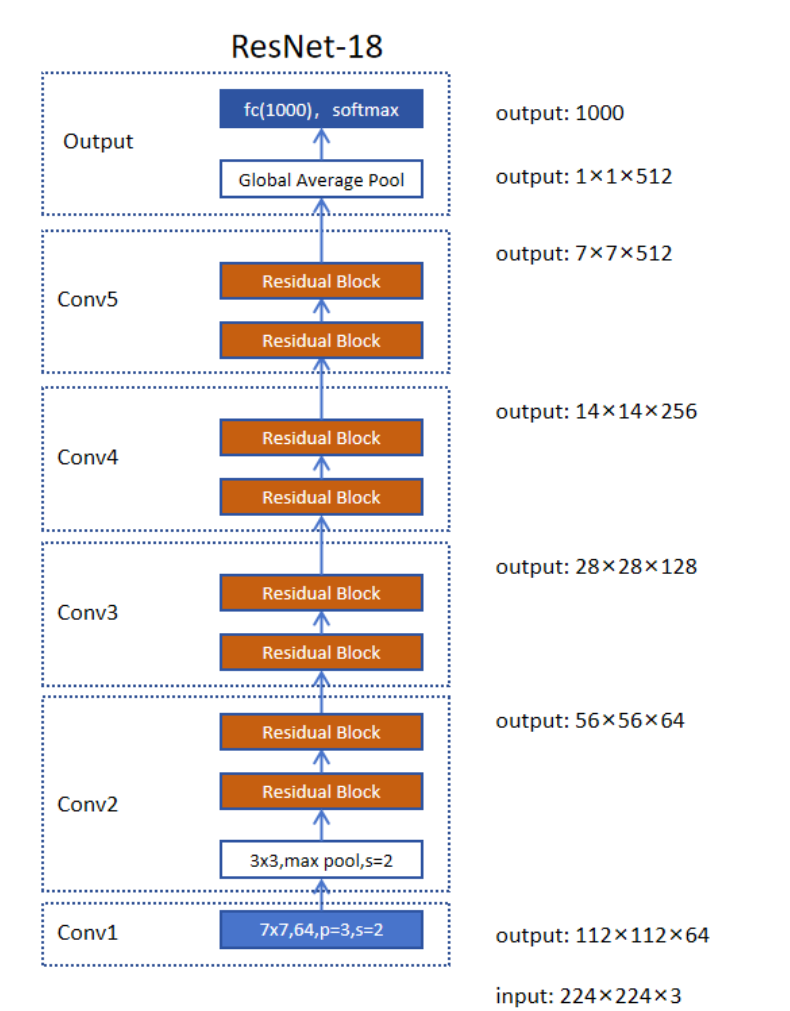

#### 不同层数ResNet架构表
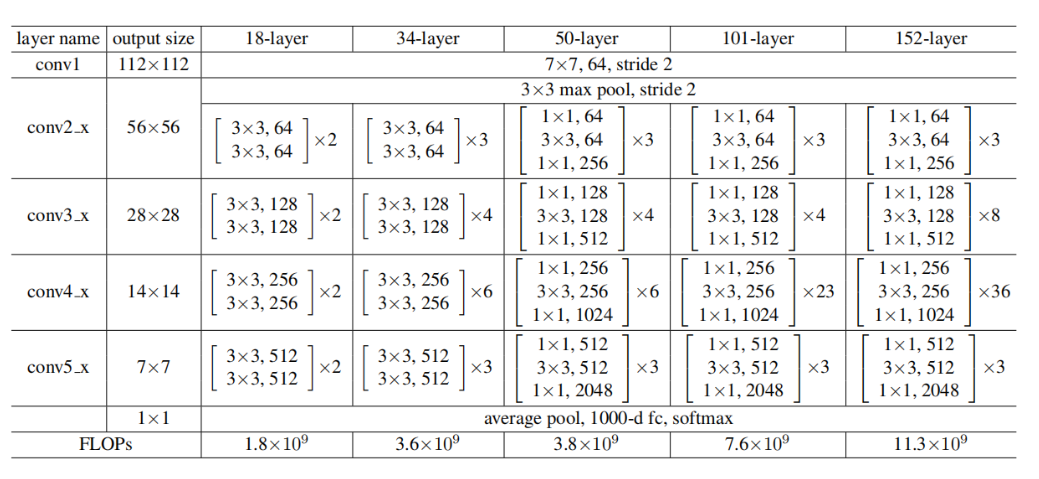
- 它们都由6个阶段构成。Conv1-Conv5，output。
- 不论ResNet有几层，它们的conv1和output阶段都一样。
- ResNet-18，ResNet-34比较类似，只是不同阶段里边的Residual Block个数不同，但是每个阶段的Residual Block都是一样的。
- ResNet-50，ResNet-101，ResNet-152比较类似，也是每个阶段的Residual Block一样，只是个数不同。

#### BasicBlock
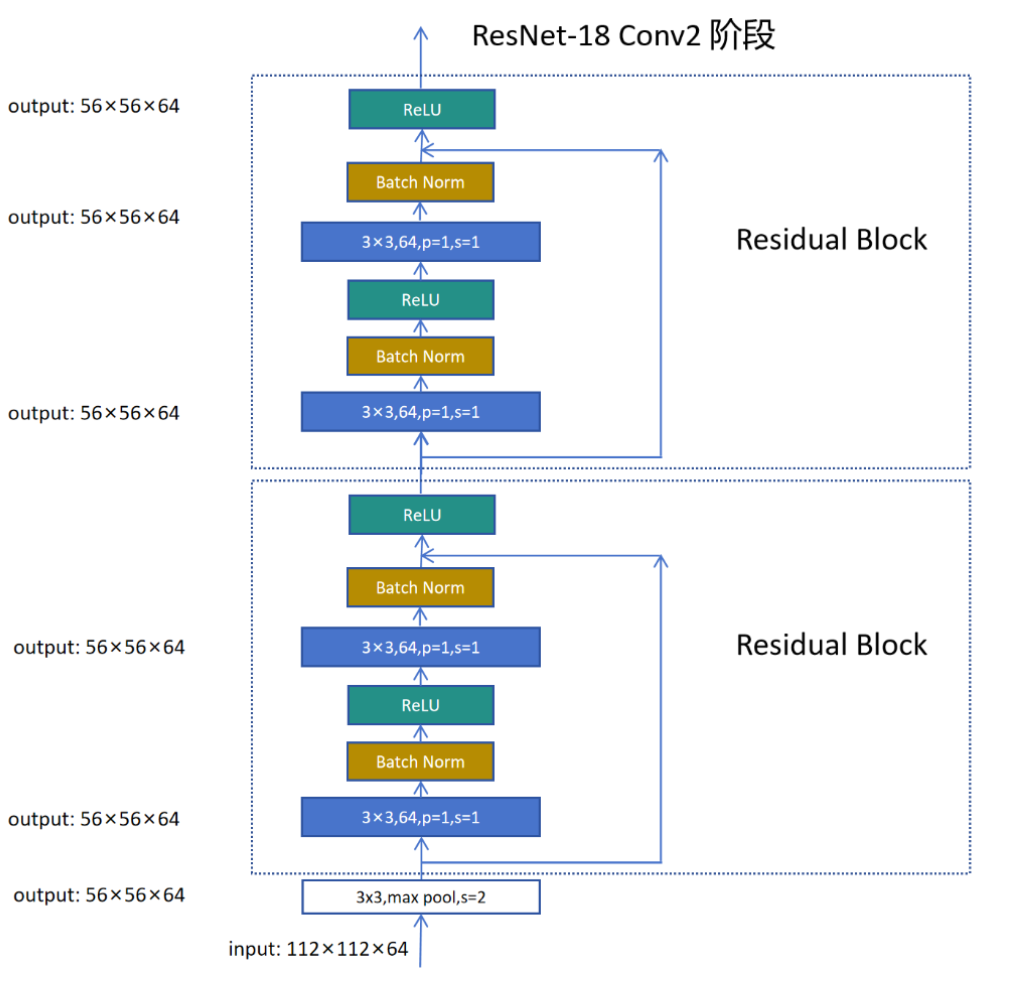
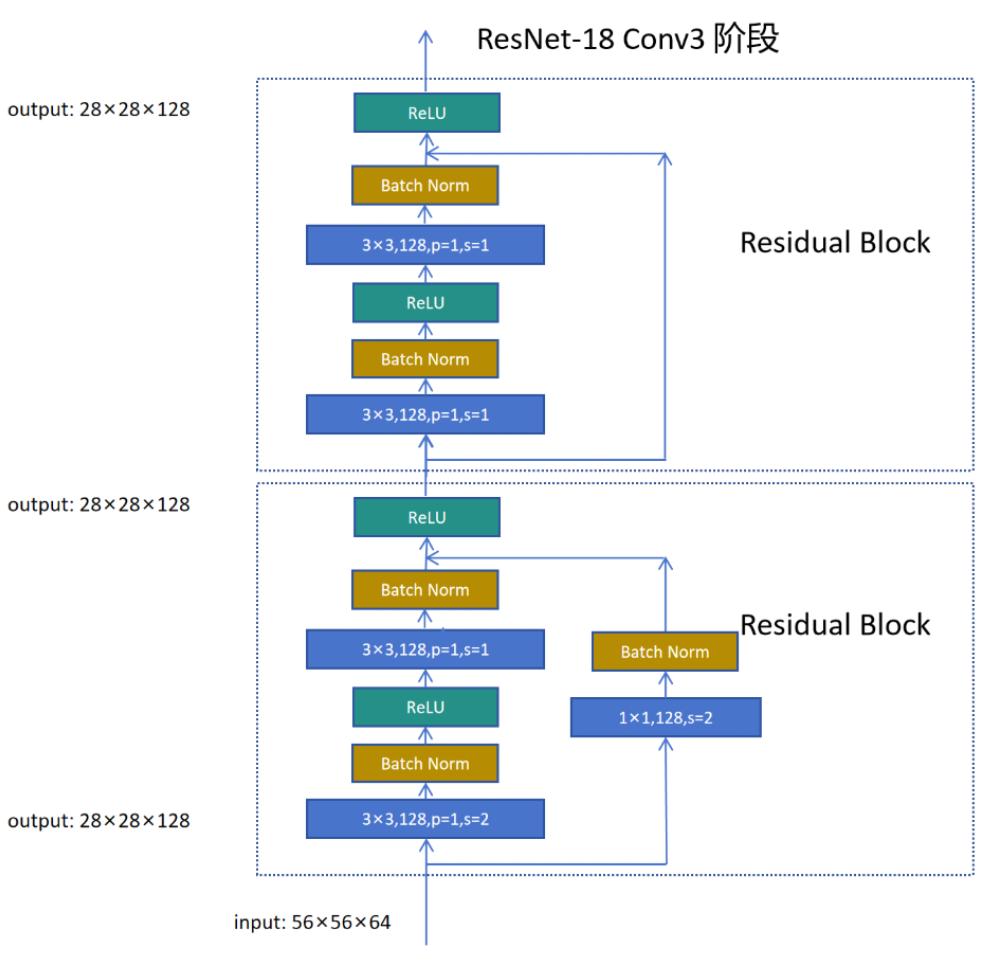

In [1]:
import torch.nn as nn


class BasicBlock(nn.Module):
    # Standard ResNet BasicBlock (v1).
    # 两个 3x3 卷积，每个卷积后跟 BN 和 ReLU。若输入输出维度不一致，则在捷径路径使用 1x1 卷积。

    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False, # 有批量归一化就不需要偏置
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu1 = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample
        self.relu2 = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        if self.downsample is not None:
            identity = self.downsample(identity)
        x += identity
        x = self.relu2(x)
        return x

#### BottleNeck
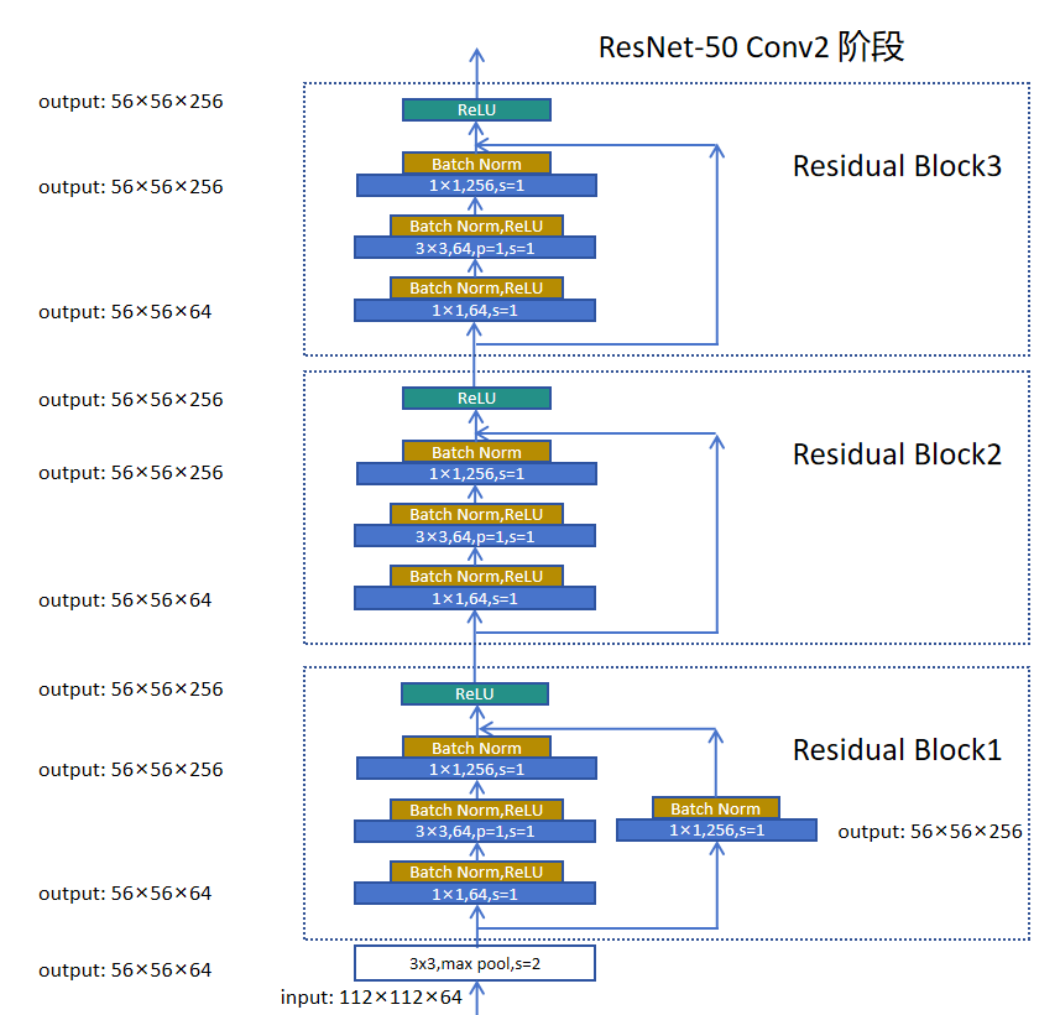
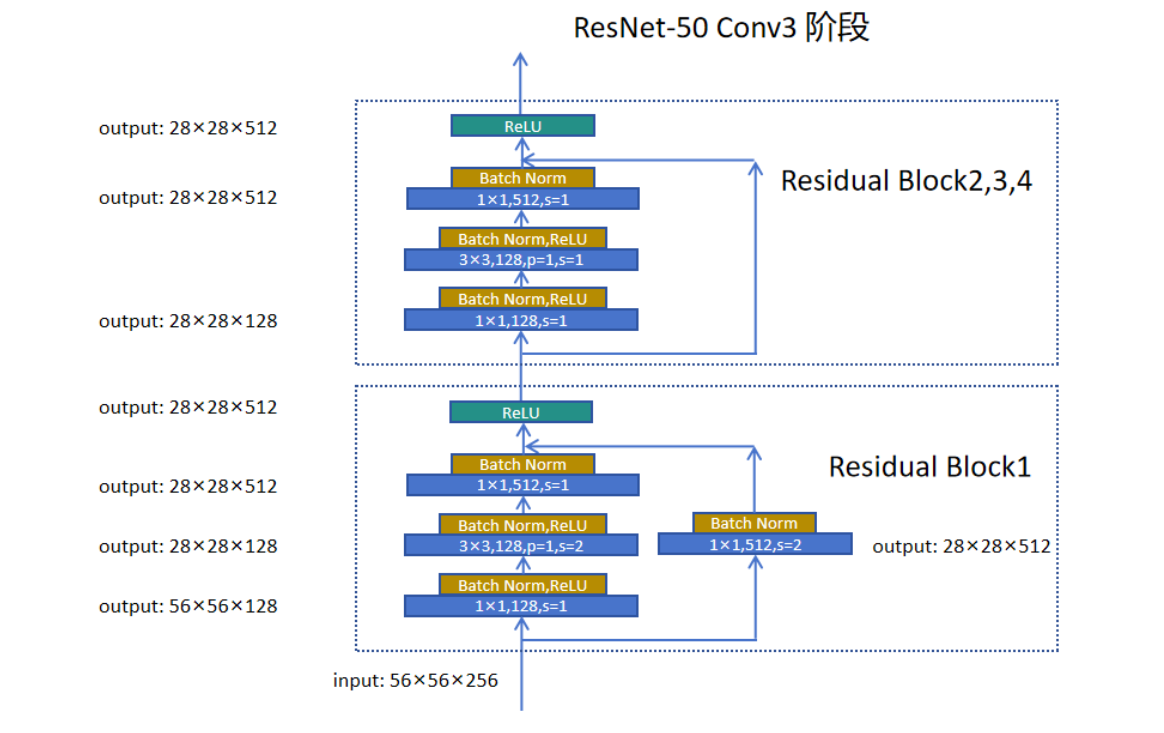

In [2]:
class BottleNeck(nn.Module):
    # Bottleneck block for deeper ResNet (v1).
    # 使用 1x1 降维 -> 3x3 卷积 -> 1x1 恢复通道数。

    expansion = 4

    def __init__(self, in_channels, mid_channels, stride=1,  downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, mid_channels, kernel_size=1,  bias=False)
        self.bn1 = nn.BatchNorm2d(mid_channels)

        self.conv2 = nn.Conv2d(mid_channels, mid_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(mid_channels)

        self.conv3 = nn.Conv2d(mid_channels, mid_channels*self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(mid_channels*self.expansion)
        self.downsample = downsample
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        identity = x

        x = self.conv1(x)
        x = self.bn1(x)

        x = self.conv2(x)
        x = self.bn2(x)

        x = self.conv3(x)
        x = self.bn3(x)
        if self.downsample is not None:
            identity = self.downsample(identity)
        x += identity
        x = self.relu(x)
        return x

#### ResNet-50
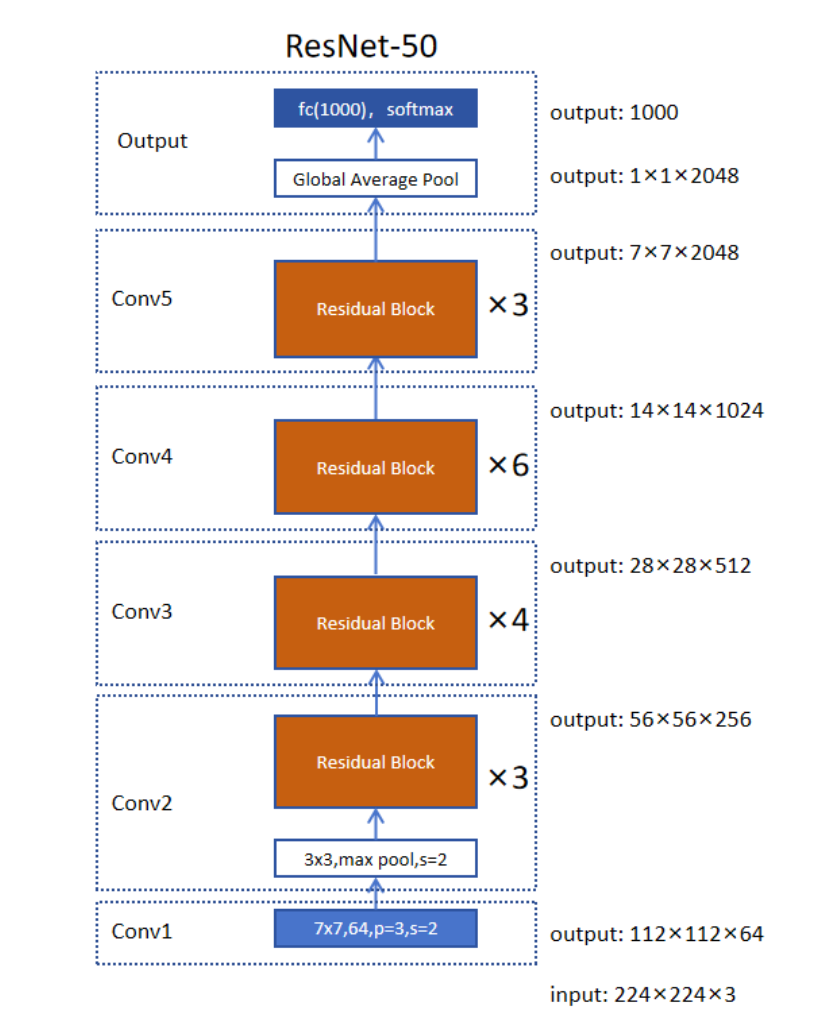

In [ ]:
import torch


class ResNet(nn.Module):
    def __init__(self, block:type[BasicBlock]|type[BottleNeck], num_blocks_in_layers, num_classes=1000):
        super().__init__()
        self.in_channels = 64

        # Conv1
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, padding=3, stride=2, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu1 = nn.ReLU(inplace=True)
        # Conv2
        self.maxPool = nn.MaxPool2d(kernel_size=3, stride=2)
        self.layer1 = self._make_layer(block, 64, num_blocks_in_layers[0])
        # Conv3
        self.layer2 = self._make_layer(block, 128, num_blocks_in_layers[1], stride=2)
        # Conv4
        self.layer3 = self._make_layer(block, 256, num_blocks_in_layers[2], stride=2)
        # Conv5
        self.layer4 = self._make_layer(block, 512, num_blocks_in_layers[3], stride=2)
        # Output
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512*block.expansion, num_classes)

    def _make_layer(
        self,
        block: type[BasicBlock]|type[BottleNeck],
        mid_channels,
        num_blocks_in_layer,
        stride=1, # 针对conv2的情况,主要保证特征图形状不变
    ):
        # 处理当层第一个残差块
        downsample = None
        out_channels = mid_channels * block.expansion
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False), 
                nn.BatchNorm2d(out_channels)
            )
        blocks = [block(self.in_channels, mid_channels, stride=stride,downsample=downsample )]
        self.in_channels = out_channels
        for _ in range(1, num_blocks_in_layer):
            blocks.append(block(self.in_channels, mid_channels))
        
        return nn.Sequential(*blocks)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.maxPool(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.gap(x)
        x = torch.flatten(x, start_dim=1)
        x = self.fc(x)

        return x


In [12]:
# 定义ResNet-18和ResNet-50
def resNet50(num_classes=1000):
    return ResNet(BottleNeck, [3, 4, 6, 3], num_classes)

def resNet18(num_classes=1000):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes)

In [14]:
# 测试模型构建
x = torch.randn((10, 3, 224, 224))
resnet50 = resNet50(num_classes=1000)
y50 = resnet50(x)
print(y50.shape)

torch.Size([10, 1000])


In [16]:
resnet18 = resNet18()
y18 = resnet18(x)
print(y18.shape)

torch.Size([10, 1000])
